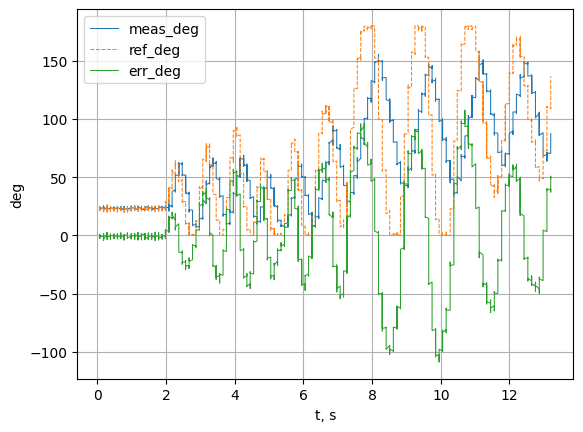

In [ ]:
import struct, time
import serial
import matplotlib.pyplot as plt

PORT = "COM11"
BAUD = 1_000_000

HDR = b"\xAA\x55"
PKT_LEN = 9

def xor_crc8(data: bytes) -> int:
    c = 0
    for b in data:
        c ^= b
    return c & 0xFF

def parse_stream(buf: bytearray):
    out = []
    while True:
        i = buf.find(HDR)
        if i < 0:
            if len(buf) > 1:
                del buf[:-1]
            break
        if i > 0:
            del buf[:i]
        if len(buf) < PKT_LEN:
            break

        pkt = bytes(buf[:PKT_LEN])
        if xor_crc8(pkt[:8]) != pkt[8]:
            del buf[0:1]
            continue

        del buf[:PKT_LEN]
        meas10, ref10, err10 = struct.unpack_from("<hhh", pkt, 2)
        out.append((meas10 / 10.0, ref10 / 10.0, err10 / 10.0))
    return out

def main():
    ser = serial.Serial(PORT, BAUD, timeout=0.05)
    time.sleep(0.2)
    ser.reset_input_buffer()

    t0 = time.time()
    ts, meas, ref, err = [], [], [], []
    buf = bytearray()

    plt.ion()
    fig, ax = plt.subplots()
    l1, = ax.plot([], [], label="meas_deg", lw=0.75)
    l2, = ax.plot([], [], label="ref_deg", ls="--", lw=0.75)
    l3, = ax.plot([], [], label="err_deg", lw=0.75)
    ax.set_xlabel("t, s")
    ax.set_ylabel("deg")
    ax.grid(True)
    ax.legend()

    try:
        while True:
            chunk = ser.read(2048)
            if chunk:
                buf.extend(chunk)
                for m, r, e in parse_stream(buf):
                    ts.append(time.time() - t0)
                    meas.append(m)
                    ref.append(r)
                    err.append(e)

            if len(ts) > 2:
                l1.set_data(ts, meas)
                l2.set_data(ts, ref)
                l3.set_data(ts, err)
                ax.relim()
                ax.autoscale_view()
                fig.canvas.draw()
                fig.canvas.flush_events()

            time.sleep(0.02)

    except KeyboardInterrupt:
        pass
    finally:
        ser.close()
        plt.ioff()
        plt.show()

if __name__ == "__main__":
    main()


In [4]:
import struct, time, threading
from collections import deque

import serial
import plotly.graph_objects as go
from IPython.display import display
import ipywidgets as widgets

PORT = "COM11"
BAUD = 1_000_000

HDR = b"\xAA\x55"
PKT_LEN = 9  # AA 55 meas(2) ref(2) err(2) crc(1)

def xor_crc8(data: bytes) -> int:
    c = 0
    for b in data:
        c ^= b
    return c & 0xFF

def parse_stream(buf: bytearray):
    out = []
    while True:
        i = buf.find(HDR)
        if i < 0:
            if len(buf) > 1:
                del buf[:-1]
            break
        if i > 0:
            del buf[:i]
        if len(buf) < PKT_LEN:
            break

        pkt = bytes(buf[:PKT_LEN])
        if xor_crc8(pkt[:8]) != pkt[8]:
            del buf[0:1]
            continue

        del buf[:PKT_LEN]
        meas10, ref10, err10 = struct.unpack_from("<hhh", pkt, 2)
        out.append((meas10 / 10.0, ref10 / 10.0, err10 / 10.0))
    return out


In [8]:
max_points = 20000  # сколько точек хранить в памяти
ts   = deque(maxlen=max_points)
meas = deque(maxlen=max_points)
ref  = deque(maxlen=max_points)
err  = deque(maxlen=max_points)

running = False
ser = None
reader_thread = None
t0 = None
pkt_counter = 0

btn_start = widgets.Button(description="Start", button_style="success")
btn_stop  = widgets.Button(description="Stop", button_style="danger", disabled=True)
btn_clear = widgets.Button(description="Clear")
lbl = widgets.Label(value="stopped")

window_mode = widgets.Dropdown(
    options=[("All time", "all"), ("Last N seconds", "win")],
    value="win",
    description="View:",
)
window_sec = widgets.IntSlider(value=10, min=1, max=60, step=1, description="N (s):")

display(widgets.HBox([btn_start, btn_stop, btn_clear, window_mode, window_sec, lbl]))

fig = go.FigureWidget()
fig.add_scatter(name="meas_deg", mode="lines", line=dict(width=1))
fig.add_scatter(name="ref_deg",  mode="lines", line=dict(width=1, dash="dash"))
fig.add_scatter(name="err_deg",  mode="lines", line=dict(width=1))

fig.update_layout(
    height=520,
    margin=dict(l=30, r=10, t=30, b=30),
    xaxis_title="t, s",
    yaxis_title="deg",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
display(fig)


FigureWidget({
    'data': [{'line': {'width': 1},
              'mode': 'lines',
              'name': 'meas_deg',
              'type': 'scatter',
              'uid': '40779215-a757-4ff7-9191-0a6e98a1f5c4'},
             {'line': {'dash': 'dash', 'width': 1},
              'mode': 'lines',
              'name': 'ref_deg',
              'type': 'scatter',
              'uid': '8775d7da-603b-4b84-a150-888985d26409'},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': 'err_deg',
              'type': 'scatter',
              'uid': '0d94bd89-d39f-4bbe-af99-cb56bf5e5b1d'}],
    'layout': {'height': 520,
               'legend': {'orientation': 'h', 'x': 1, 'xanchor': 'right', 'y': 1.02, 'yanchor': 'bottom'},
               'margin': {'b': 30, 'l': 30, 'r': 10, 't': 30},
               'template': '...',
               'xaxis': {'title': {'text': 't, s'}},
               'yaxis': {'title': {'text': 'deg'}}}
})

In [10]:
def reader_loop():
    global running, ser, t0, pkt_counter
    buf = bytearray()
    last_ui = time.time()
    last_rate_t = time.time()
    last_rate_n = 0

    while running:
        try:
            chunk = ser.read(4096)
            if chunk:
                buf.extend(chunk)
                for m, r, e in parse_stream(buf):
                    now = time.time()
                    ts.append(now - t0)
                    meas.append(m)
                    ref.append(r)
                    err.append(e)
                    pkt_counter += 1

            now = time.time()

            # обновление UI ~ 20 раз/сек, чтобы не тормозить
            if now - last_ui >= 0.05 and len(ts) > 2:
                last_ui = now

                # выбор диапазона по X
                if window_mode.value == "all":
                    xs = list(ts)
                    ys1, ys2, ys3 = list(meas), list(ref), list(err)
                else:
                    W = window_sec.value
                    t_end = ts[-1]
                    t_start = t_end - W
                    # найдём индекс начала окна (линейно; для 20k точек норм)
                    xs_all = list(ts)
                    k = 0
                    for i, x in enumerate(xs_all):
                        if x >= t_start:
                            k = i
                            break
                    xs = xs_all[k:]
                    ys1, ys2, ys3 = list(meas)[k:], list(ref)[k:], list(err)[k:]

                with fig.batch_update():
                    fig.data[0].x = xs; fig.data[0].y = ys1
                    fig.data[1].x = xs; fig.data[1].y = ys2
                    fig.data[2].x = xs; fig.data[2].y = ys3

            # расчёт скорости пакетов/сек
            if now - last_rate_t >= 1.0:
                rate = pkt_counter - last_rate_n
                last_rate_n = pkt_counter
                last_rate_t = now
                lbl.value = f"running | {rate} pkt/s | points={len(ts)}"

        except Exception as ex:
            lbl.value = f"error: {ex}"
            break

    lbl.value = "stopped"

def start(_=None):
    global running, ser, reader_thread, t0, pkt_counter
    if running:
        return
    pkt_counter = 0
    ser = serial.Serial(PORT, BAUD, timeout=0.05)
    time.sleep(0.2)
    ser.reset_input_buffer()
    t0 = time.time()
    running = True

    btn_start.disabled = True
    btn_stop.disabled = False

    reader_thread = threading.Thread(target=reader_loop, daemon=True)
    reader_thread.start()

def stop(_=None):
    global running, ser
    running = False
    btn_start.disabled = False
    btn_stop.disabled = True
    try:
        if ser is not None:
            ser.close()
    except:
        pass

def clear(_=None):
    ts.clear(); meas.clear(); ref.clear(); err.clear()
    with fig.batch_update():
        for i in range(3):
            fig.data[i].x = []
            fig.data[i].y = []
    lbl.value = "cleared"

btn_start.on_click(start)
btn_stop.on_click(stop)
btn_clear.on_click(clear)

lbl.value = "ready"
